### 불용어, 단어 빈도, 워드클라우드
- 자주 나온다 -> 중요, 개수를 세야한다 -> 그 문서의 주제
- 불용어 처리 전 vs 후 비교
- 워드 클라우드 핵심단어


- 어떤 문서가 무엇을 다루는 지 -> 빈도 높은 단어
- 모든 문서에서 흔한 단어 -> 의미는 매우 낮다
- ex)
    - 뉴스 기사에 흔한 단어 : 기자, 뉴스,연합뉴스 -> 제거 대상 


### 1. 준비

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from kiwipiepy import Kiwi

plt.rcParams["font.family"] = "Malgun Gothic"   # 한글 깨짐 방지(윈도우 기본 폰트)
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv("../data/11-1_뉴스정제.csv")
kiwi = Kiwi()

In [78]:
# 명사 추출 함수 만들기

def extract_nonus(text):
    nonus =[]
    result = kiwi.tokenize(text)
    for token in result:
        if token.tag.startswith("N"): # N으로 시작하는 글자가 명사
            nonus.append(token.form) # 실제명사만 넣기

    filtered_nouns = []
    for noun in nonus : 
         if len(noun)> 1:
                filtered_nouns.append(noun)
    return filtered_nouns


# 모든 기사의 명사를 한곳에서 한눈에 보기

In [79]:
all_nouns =[]
df['명사'] = df['정제본문'].apply(extract_nonus)
df[['정제본문','명사']].head()


,정제본문,명사
0,서울 연합뉴스 현대백화점그룹이 광주광역시에 서울 여의도 더현대 서울 과 같은 문화복...,"[서울, 연합뉴스, 현대백화점그룹, 광주광역시, 서울, 여의도, 현대, 서울, 문화..."
1,전주 뉴시스 김얼 기자 이스타항공 자금 배임 횡령으로 전주교도소에 수감됐었던 이상직...,"[전주, 뉴시스, 김얼, 기자, 이스타항공, 자금, 배임, 횡령, 전주, 교도소, ..."
2,NH농협은행은 올해 농협금융 출범 10주년을 맞아 이달 29일까지 10주년 기념주화...,"[NH농협은행, 올해, 농협, 금융, 출범, 주년, 이달, 주년, 기념, 주화, 대..."
3,img tag s 지난 30일 서울의 한 주유소 사진 연합뉴스 img tag e 오...,"[서울, 주유소, 사진, 연합뉴스, 오늘, 유류, 세율, 인하, 확대, 올해, 분기..."
4,파이낸셜뉴스 푸르덴셜생명보험은 급변하는 금융시장에 대응하기 위해 무배당 더 큰 드림...,"[파이낸셜뉴스, 푸르덴셜생명보험, 급변, 금융, 시장, 대응, 배당, 드림, 연금,..."


In [80]:
for doc_nouns in df['명사']:
    all_nouns.extend(doc_nouns)
print(len(all_nouns))

179518


In [81]:
from collections import Counter

count_result = Counter(all_nouns)
count_result.most_common(10)

[('기업', 999),
 ('서비스', 920),
 ('사업', 851),
 ('기술', 777),
 ('제공', 748),
 ('시장', 687),
 ('개발', 657),
 ('국내', 599),
 ('투자', 592),
 ('가능', 557)]

In [82]:
#불용어
#의미없는 단어 - 그 단어 삭제
stopwords = ['기자','연합뉴스','뉴스']

filtered_all_nouns = []

for noun in all_nouns:
    if noun not in stopwords:
        filtered_all_nouns.append(noun)

In [83]:
count_after =Counter(filtered_all_nouns)
count_after.most_common(20)

[('기업', 999),
 ('서비스', 920),
 ('사업', 851),
 ('기술', 777),
 ('제공', 748),
 ('시장', 687),
 ('개발', 657),
 ('국내', 599),
 ('투자', 592),
 ('가능', 557),
 ('올해', 544),
 ('계획', 541),
 ('대표', 530),
 ('서울', 524),
 ('금융', 522),
 ('지원', 506),
 ('정보', 503),
 ('진행', 491),
 ('고객', 461),
 ('이번', 456)]

In [84]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

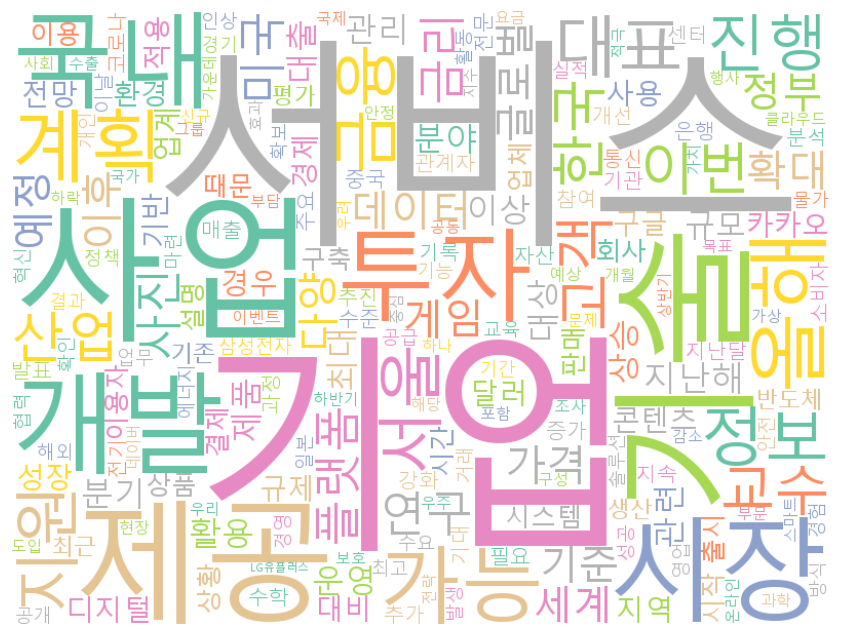

In [85]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Windows 한글 폰트 경로
font_path = "C:/Windows/Fonts/malgun.ttf"

wordcloud = WordCloud(
    font_path=font_path,
    width=800,
    height=600,
    background_color="white",
    colormap="Set2"
).generate_from_frequencies(count_after)

plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")  # 축 숨기기
plt.show()

# 이미지 파일로도 저장
wordcloud.to_file("news_wordcloud.png")

In [86]:
#리뷰데이터 사용하여 워드클라우드 사용
import re # 정규표현식을 사용하는 모듈
jeju = pd.read_csv("../data/11-1_visitjeju_reviews.csv",encoding='cp949')
#제주라는 변수에 패키지는 판다스를 사용하여 데이터 프레임을 불러온다



In [87]:
def clean_review(text):
    text = str(text)

    text = re.sub(r"https?://\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    text = re.sub(r"[^가-힣a-zA-Z0-9\sㅋㅎㅠㅜ]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [88]:
def clean_review(text):
    text = str(text)
    text = re.sub(r"https?://\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    text = re.sub(r"[^가-힣a-zA-Z0-9\sㅋㅎㅠㅜ]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

jeju["정제리뷰"] = jeju["리뷰내용"].fillna("").apply(clean_review) 
# 리뷰내용에 결측치를  빈  문자열으로 파라미터 조건

In [89]:
kiwi = Kiwi()

def extract_nouns(text):
    return [
        token.form
        for token in kiwi.tokenize(str(text))
        if token.tag.startswith("N")
        and len(token.form) > 1
    ]


jeju["제주명사"] = jeju["정제리뷰"].apply(extract_nouns)
  # 여기에 교체 코드


In [90]:
words = [
    word
    for nouns in jeju["제주명사"]
    for word in nouns
    if word not in ["제주", "제주도","여행","정답",
                    "시작","바다","정도","가족",
                    "한라산","힐링","친구","방문",
                    "감사","생각","사진","자연",
                    "추천","겨울","가을","사람",
                    "우도","시간","풍경","추억"]
]

frequencies = Counter(words)

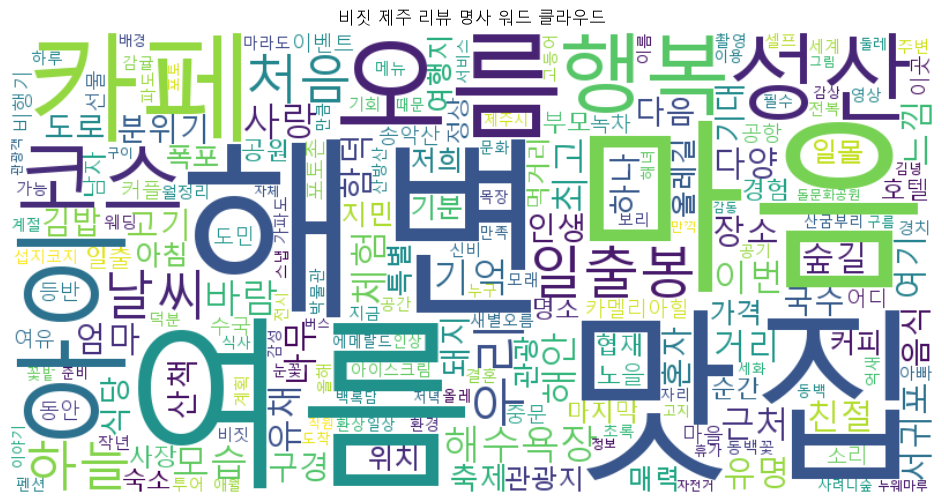

In [91]:
wordcloud = WordCloud(
    font_path="C:/Windows/Fonts/malgun.ttf",
    background_color="white",
    width=800,
    height=400
).generate_from_frequencies(frequencies)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.title("비짓 제주 리뷰 명사 워드 클라우드")
plt.axis("off")
plt.show()


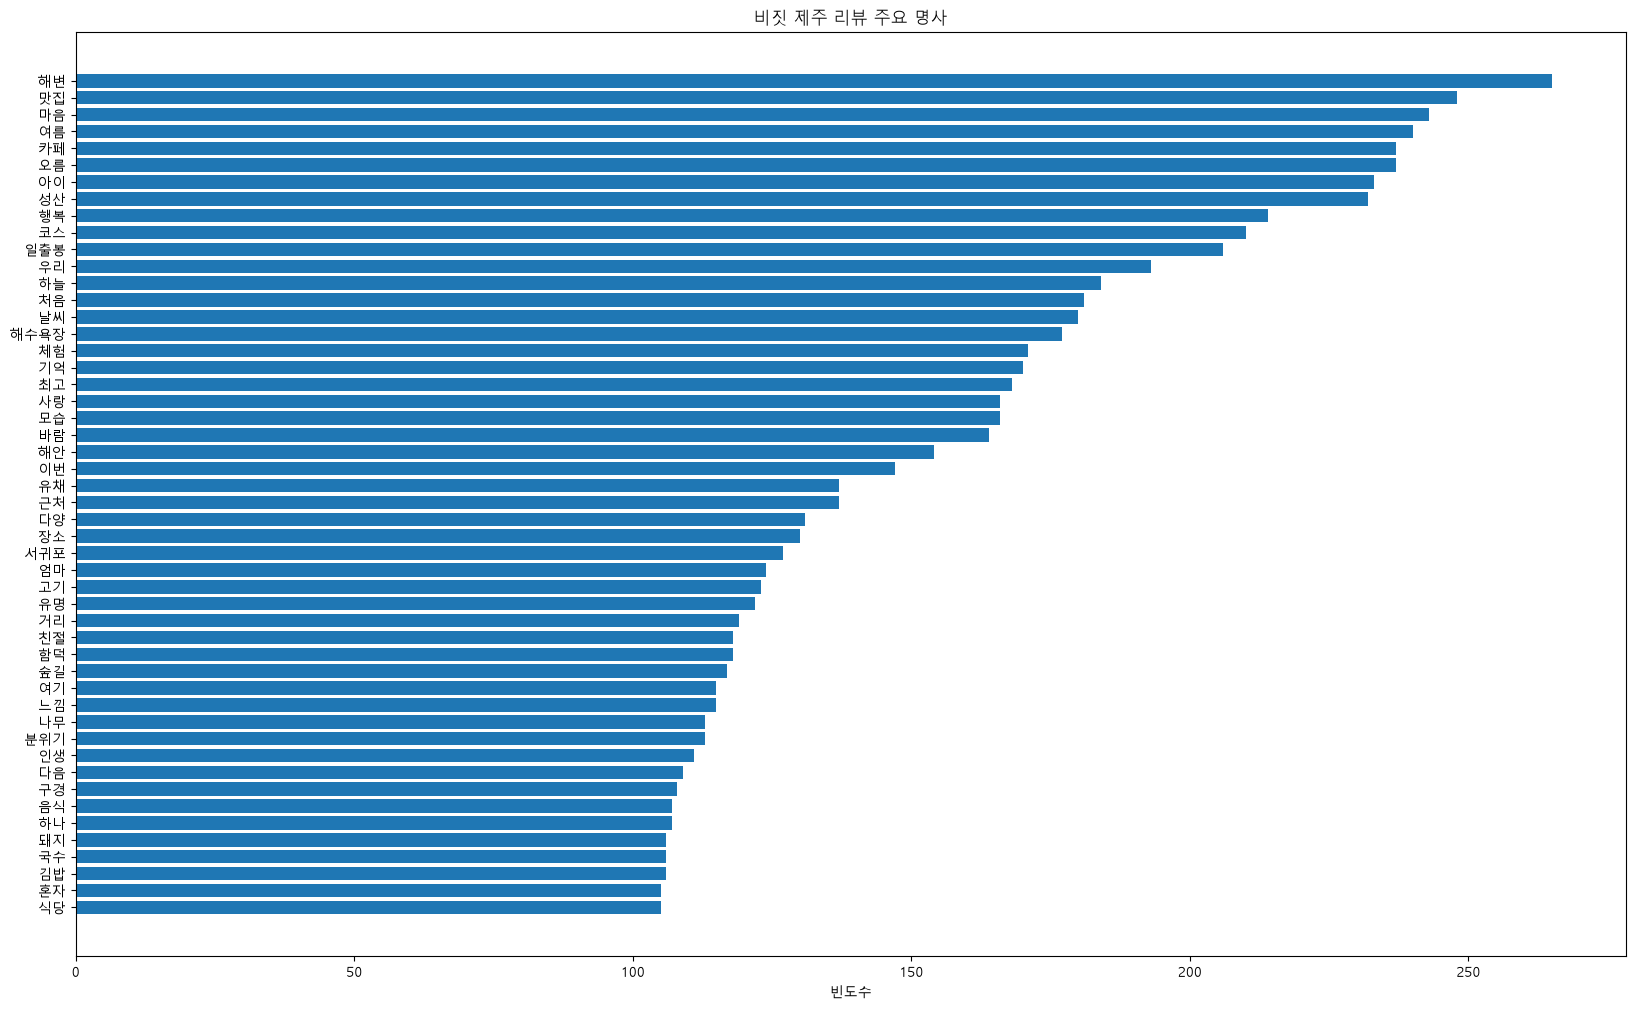

In [92]:
frequencies = Counter(words) 

top_words = frequencies.most_common(50)

words_top = [x[0] for x in top_words]
counts_top = [x[1] for x in top_words]

plt.figure(figsize=(20, 12))
plt.barh(words_top[::-1], counts_top[::-1])
plt.xlabel("빈도수")
plt.title("비짓 제주 리뷰 주요 명사")
plt.show()
